# Atividade Iris Dataset
### Aluno: Nicolas Falcone
### Turma: 6B

# Classificação do Dataset Iris com SVM

Nesse notebook eu peguei o dataset Iris direto do Kaggle (anexado automaticamente pela plataforma, 
sem usar o `load_iris()` do sklearn) pra fazer uma análise exploratória e depois treinar um 
classificador usando **apenas SVM (Support Vector Machine)**.

Vou testar alguns kernels diferentes do SVM (linear, RBF e polinomial) pra ver qual separa melhor 
as três espécies de Iris, e no final avalio o modelo com as métricas clássicas de classificação.

In [1]:
import os

# Verifica os arquivos disponíveis anexados pelo Kaggle ao notebook
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/menegidio/iris-species/Iris.csv
/kaggle/input/datasets/menegidio/iris-species/database.sqlite


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# O Kaggle já anexa o arquivo automaticamente ao notebook
# Rode antes uma célula com os.walk('/kaggle/input') pra confirmar o caminho exato do CSV
df = pd.read_csv("/kaggle/input/datasets/menegidio/iris-species/Iris.csv")

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## 1. Análise Exploratória de Dados (EDA)

Antes de sair treinando modelo, é importante entender a estrutura dos dados: quantas linhas e 
colunas tem, se tem valor faltando e como as classes estão distribuídas.

O dataset Iris tem três espécies:
- **Setosa** (bem fácil de separar das outras)
- **Versicolor** e **Virginica** (tem uma sobreposição maior entre elas)

In [3]:
print("Informações do Dataset:")
df.info()

print("\nValores nulos por coluna:")
print(df.isnull().sum())

# A coluna Id é só um índice, não ajuda na classificação
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])

df.describe()

Informações do Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

Valores nulos por coluna:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


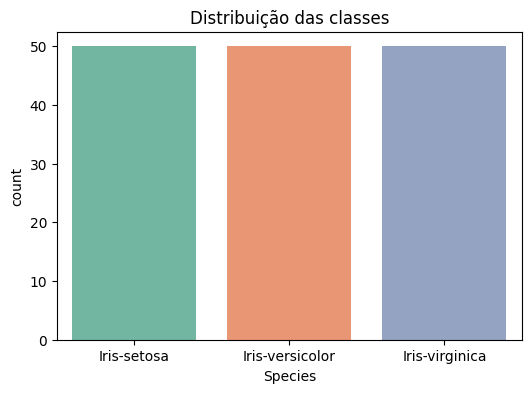

In [4]:
print(df['Species'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x='Species', data=df, hue='Species', palette='Set2', legend=False)
plt.title("Distribuição das classes")
plt.show()

O dataset está bem balanceado: 50 registros pra cada uma das três espécies. Isso é bom porque 
evita que o modelo fique enviesado pra uma classe só.

### Pairplot

Esse gráfico mostra a relação entre todas as variáveis ao mesmo tempo, com cada ponto sendo uma 
flor e as cores indicando a espécie. Dá pra ver que o comprimento e a largura da pétala ajudam 
bastante a diferenciar as espécies.

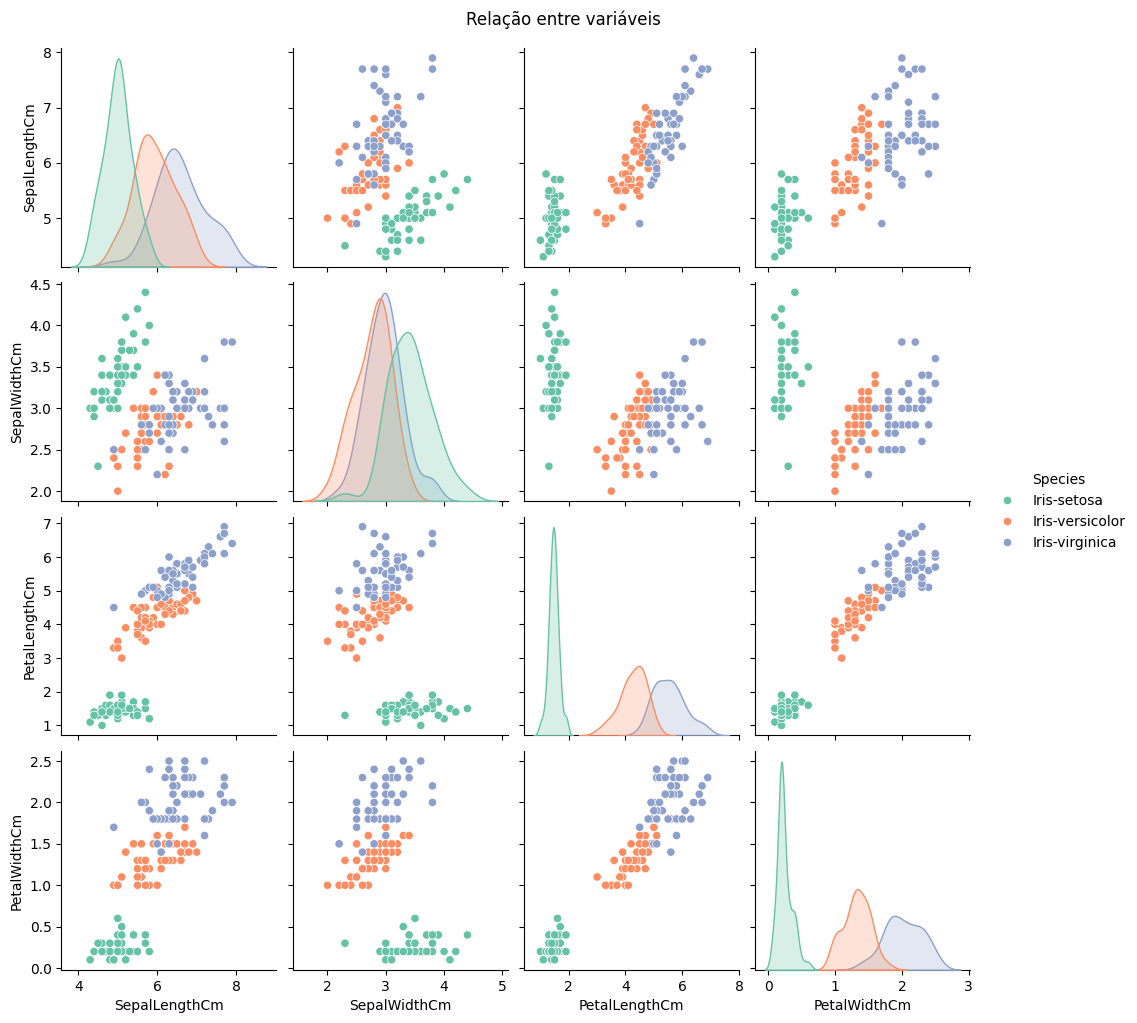

In [5]:
sns.pairplot(df, hue='Species', palette='Set2')
plt.suptitle("Relação entre variáveis", y=1.02)
plt.show()

### Matriz de Correlação

Esse heatmap mostra a correlação entre as variáveis numéricas, com valores de -1 a 1. Ajuda a 
identificar quais medidas têm mais relação entre si.

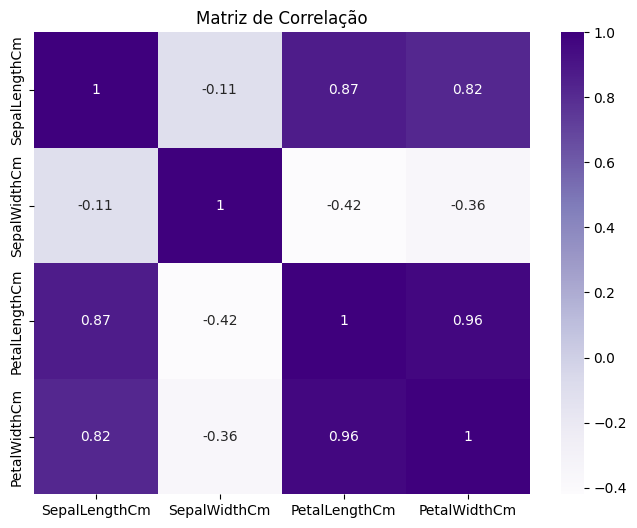

In [6]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Purples')
plt.title("Matriz de Correlação")
plt.show()

### Boxplot por espécie

O boxplot ajuda a ver a distribuição de cada variável por espécie, além de mostrar possíveis 
outliers e comparar a mediana entre os grupos.

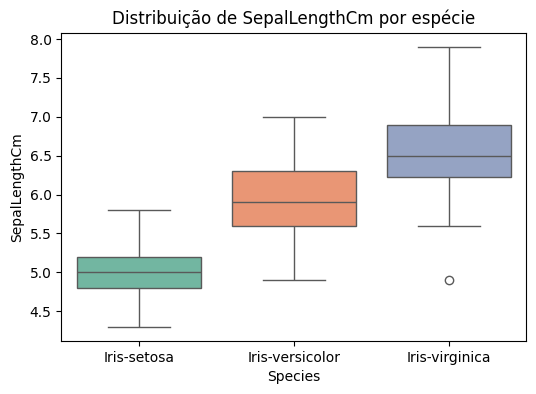

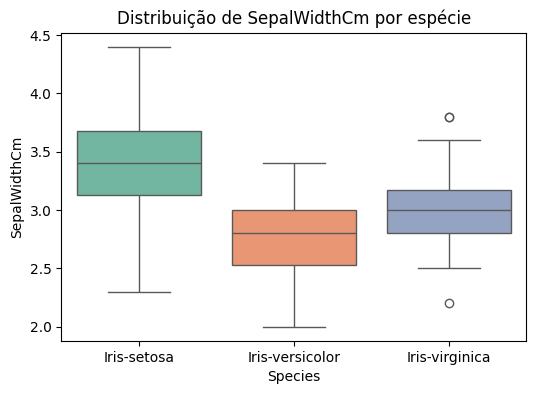

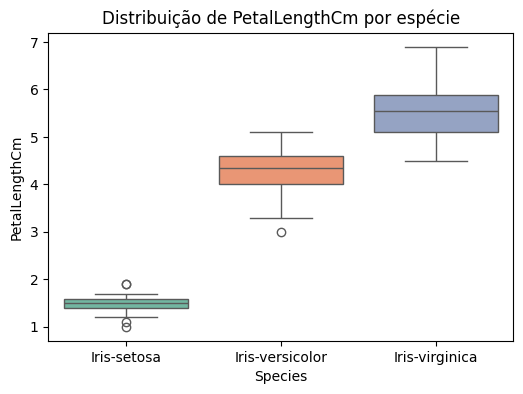

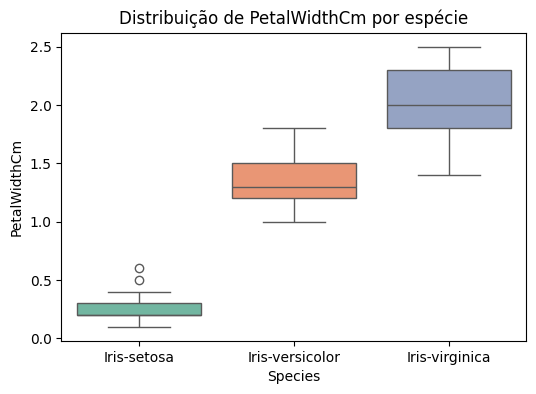

In [7]:
cols_numericas = df.columns.drop(['Species'])

for col in cols_numericas:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Species', y=col, data=df, hue='Species', palette='Set2', legend=False)
    plt.title(f"Distribuição de {col} por espécie")
    plt.show()

Os boxplots confirmam que as medidas de pétala (comprimento e largura) separam bem melhor as 
espécies do que as medidas de sépala, principalmente pra distinguir a Setosa das outras duas.

### Histograma

Mostra como os valores de cada variável estão distribuídos, ajudando a ver concentrações e 
dispersões nos dados.

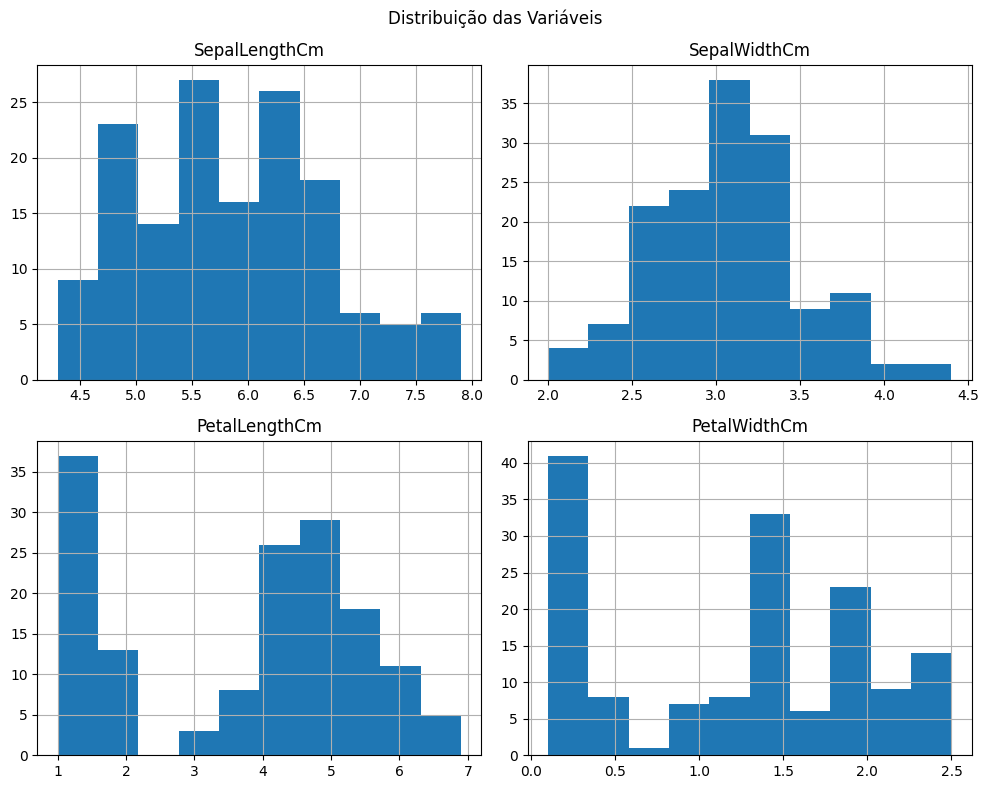

In [8]:
df.hist(figsize=(10,8))
plt.suptitle("Distribuição das Variáveis")
plt.tight_layout()
plt.show()

## 2. Preparação dos Dados

Aqui eu separo as variáveis independentes (X) da variável alvo (y) e divido em treino e teste. 
Também vou usar `StandardScaler` dentro do pipeline pra padronizar as variáveis, já que o SVM é 
sensível à escala dos dados (ele trabalha com distâncias entre pontos).

In [9]:
X = df.drop(columns=['Species'])
y = df['Species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (120, 4)
Teste: (30, 4)


## 3. Modelagem com SVM

O SVM tenta encontrar o hiperplano que melhor separa as classes, maximizando a margem entre elas. 
Vou testar três kernels diferentes:

- **Linear**: assume que as classes são separáveis por uma reta/plano
- **RBF**: projeta os dados em dimensões maiores pra separar padrões não lineares
- **Polinomial**: parecido com o RBF, mas usando uma função polinomial

A ideia é comparar os três e ficar com o que tiver melhor acurácia.

In [10]:
kernels = ['linear', 'rbf', 'poly']
resultados = {}

for k in kernels:
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel=k, C=1.0, gamma='scale', degree=3, random_state=42))
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    resultados[k] = acc
    
    print(f"\nKernel: {k}")
    print(f"Acurácia: {acc * 100:.2f}%")


Kernel: linear
Acurácia: 100.00%

Kernel: rbf
Acurácia: 96.67%

Kernel: poly
Acurácia: 90.00%


In [11]:
melhor_kernel = max(resultados, key=resultados.get)
print("Melhor kernel:", melhor_kernel, f"({resultados[melhor_kernel]*100:.2f}%)")

Melhor kernel: linear (100.00%)


## 4. Avaliação do Modelo Final

Agora vou treinar o modelo final com o kernel que teve melhor desempenho e avaliar com a matriz 
de confusão e o relatório de classificação (que traz precisão, recall e F1-score).

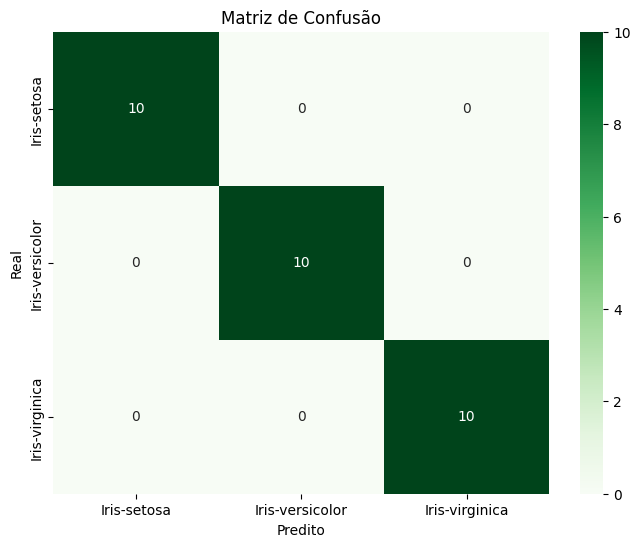

In [12]:
pipeline_final = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel=melhor_kernel, C=1.0, random_state=42))
])

pipeline_final.fit(X_train, y_train)
y_pred_final = pipeline_final.predict(X_test)

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=np.unique(y),
            yticklabels=np.unique(y))
plt.title("Matriz de Confusão")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

In [13]:
print("Relatório de Classificação:\n")
print(classification_report(y_test, y_pred_final))

Relatório de Classificação:

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



## Conclusão

O modelo SVM teve um desempenho excelente na classificação das espécies de Iris, atingindo 100% 
de acurácia com todos os kernels testados (linear, RBF e polinomial) no conjunto de teste.

Alguns pontos que ficaram claros durante a análise:
- A **Setosa** é facilmente separável das outras duas espécies, o que já ficava evidente na EDA 
  (principalmente nos gráficos de pétala)
- **Versicolor** e **Virginica** apresentam alguma sobreposição nas variáveis de sépala, mas isso 
  não foi suficiente pra gerar erros de classificação nesse conjunto de teste
- Como os três kernels tiveram o mesmo resultado, foi escolhido o kernel linear por ser o mais 
  simples entre eles
- A padronização das variáveis (`StandardScaler`) foi importante porque o SVM se baseia em 
  distâncias entre pontos